# DFL 7경기 xG 모델

맨 위 0번 셀이 데이터 준비부터 학습·평가까지 전부 다시 계산하고, 나머지 셀이 그 결과로 표와 그래프를 그린다.
이미 계산된 결과만 보려면 0번 셀의 `RUN_PIPELINE`을 `False`로 바꾸고 실행한다. 필요한 환경과 데이터는 `README.md` 참고.

VS Code에서는 오른쪽 위 커널 선택에서 Python 3.12 환경을 고른다.

| 섹션 | 내용 |
|---|---|
| 0 | 결과 만들기 (파이프라인 실행) |
| 1 | 데이터 요약 · 슛맵 · 거리별 득점률 |
| 2 | 슛 한 개 들여다보기 — StatsBomb 프리즈프레임 vs DFL 트래킹 |
| 3 | 성능 — 개발 CV vs 최종 테스트 · 캘리브레이션 · ROC · 서브그룹 |
| 4 | 피처 하나만으로 골을 얼마나 가르나 |
| 5 | DFL — StatsBomb 사전학습(v2) vs DFL 단독 |

## 0. 결과 만들기

`Dfl/`에 DFL 원본 XML 21개가 있으면 전체 파이프라인(`run_all.py`)을 돌린다.
없으면 저장소에 들어 있는 DFL 가공 결과(`out/ds_dfl.csv` 등)를 그대로 쓰고, StatsBomb 쪽만 원본 다운로드부터 다시 계산한다.

In [1]:
import os, sys, glob, subprocess
RUN_PIPELINE = True        # False로 두면 계산은 건너뛰고 이미 있는 out/ 결과만 읽는다

ROOT = os.path.abspath("")
while not os.path.exists(os.path.join(ROOT, "run_all.py")) and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)

def run(*args):
    """파이썬 스크립트를 실행하며 출력을 그대로 보여주고, 실패하면 여기서 멈춘다."""
    p = subprocess.Popen([sys.executable, "-X", "utf8", *args], cwd=ROOT, stdout=subprocess.PIPE,
                         stderr=subprocess.STDOUT, text=True, encoding="utf-8", errors="replace",
                         env={**os.environ, "PYTHONIOENCODING": "utf-8"})
    for line in p.stdout:
        print(line, end="", flush=True)
    if p.wait() != 0:
        raise RuntimeError("실패: " + " ".join(args))

if RUN_PIPELINE:
    if len(glob.glob(os.path.join(ROOT, "Dfl", "DFL_0[234]_*.xml"))) >= 21:
        print("DFL 원본 있음 -> 전체 파이프라인 실행\n")
        run("run_all.py", "-q")
    else:
        print("DFL 원본 없음 -> DFL은 저장소의 가공 결과를 쓰고, StatsBomb만 처음부터 계산\n")
        run("src/fetch_statsbomb.py")
        run("src/build_dataset.py", "statsbomb")
        run("run_all.py", "--from", "train", "-q")

DFL 원본 있음 -> 전체 파이프라인 실행

실행할 단계 8개: matchinfo -> events -> freeze -> statsbomb -> dataset -> train -> finetune -> dfl_only

[1/8] matchinfo  - DFL 경기정보 -> out/matches.csv, players.csv
    {'ORM': 21, 'STZ': 19, 'ZO': 17, 'OLM': 17, 'IVL': 16, 'IVR': 16, 'LV': 15, 'DML': 15, 'RV': 14, 'TW': 14, 'DMR': 13, 'STL': 8, 'STR': 8, 'DMZ': 4, 'HL': 4, 'DLM': 3, 'HR': 3, 'IVZ': 3, 'RA': 2, 'DRM': 2, 'RM': 2, 'LA': 1, 'LM': 1}
    완료 (2초)

[2/8] events  - DFL 이벤트 -> out/shots.csv
    DFL-MAT-J03WR9     27      3
    완료 (4초)

[3/8] freeze  - DFL 트래킹 2.5GB -> out/freeze_frames.parquet
    dtype: object
    완료 (74초)

[4/8] statsbomb  - StatsBomb La Liga 15/16 다운로드 (있으면 건너뜀)
    [done] 380경기  받음=0 건너뜀=380 실패=0  108MB  1.0분
    완료 (57초)

[5/8] dataset  - 공용 피처 -> out/ds_statsbomb.csv, ds_dfl.csv
    [dfl]       159슛 16골  3s -> out/ds_dfl.csv
    완료 (79초)

[6/8] train  - v1 학습·평가 -> out/v1_results.csv, v1_oof.csv
    -> out/v1_results.csv, out/v1_oof.csv  (210s)
    완료 (214초)

[7/8] finetune  - v2 DFL

In [2]:
import os, sys, gzip, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from matplotlib.patches import Arc, Polygon
from sklearn.metrics import roc_auc_score, roc_curve
from IPython.display import display

ROOT = os.path.abspath("")                     # 노트북 위치에서 run_all.py가 있는 폴더를 찾아 올라간다
while not os.path.exists(os.path.join(ROOT, "run_all.py")) and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)
sys.path.insert(0, os.path.join(ROOT, "src"))
import geometry as G
from train_v1 import BASE_NUM, EVT_NUM, FF_NUM

OUT = os.path.join(ROOT, "out")
SB_DIR = os.path.join(ROOT, "data", "statsbomb", "comp11_season27")
pd.set_option("display.max_columns", 40, "display.width", 200)

# 색은 역할별로 여기서만 정의
INK, INK2, MUTED, GRID, BASE, SURF = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
_fonts = {f.name for f in fm.fontManager.ttflist}
plt.rcParams.update({
    "font.family": next((f for f in ["Malgun Gothic", "AppleGothic", "NanumGothic"] if f in _fonts), "sans-serif"),
    "axes.unicode_minus": False, "font.size": 10, "figure.dpi": 110,
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": BASE, "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED,
    "text.color": INK, "axes.titlecolor": INK, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "legend.frameon": False,
})
print("ROOT =", ROOT)

ROOT = C:\xg


## 1. 데이터

In [3]:
sb_all = pd.read_csv(os.path.join(OUT, "ds_statsbomb.csv"))
sb = sb_all[sb_all.shot_type != "Penalty"].reset_index(drop=True)   # 평가 대상은 비페널티 슛
dfl = pd.read_csv(os.path.join(OUT, "ds_dfl.csv"))
oof = pd.read_csv(os.path.join(OUT, "v1_oof.csv"))      # 슛마다 '그 경기를 안 본 모델'의 예측 (dev: CV, test: 최종 모델)
res = pd.read_csv(os.path.join(OUT, "v1_results.csv"))
shots = pd.read_csv(os.path.join(OUT, "shots.csv"))     # DFL 이벤트 원본 (위치·선수)
assert (oof.shot_id.values == sb.shot_id.values).all()
SEL = res[res.selected].iloc[0]                         # dev CV로 고른 최종 모델
sb["xg_ours"] = oof[f"{SEL.variant}_{SEL.model}"].values
sb["split"] = oof.split.values
y = sb.goal.values
print(f"최종 모델: {SEL.variant} {SEL.label} · {SEL.model}")

pd.DataFrame({
    "경기": [sb.match_id.nunique(), dfl.match_id.nunique()],
    "슛 (비페널티)": [len(sb), len(dfl)],
    "골": [sb.goal.sum(), dfl.goal.sum()],
    "득점률": [f"{sb.goal.mean():.1%}", f"{dfl.goal.mean():.1%}"],
    "선수 위치": ["프리즈프레임 — 화면에 보인 선수만", "트래킹 25Hz — 22명 전원"],
}, index=["StatsBomb 라리가 15/16", "DFL 7경기"])

최종 모델: C +프리즈프레임 · LogReg


,경기,슛 (비페널티),골,득점률,선수 위치
StatsBomb 라리가 15/16,380,9071,945,10.4%,프리즈프레임 — 화면에 보인 선수만
DFL 7경기,7,159,16,10.1%,트래킹 25Hz — 22명 전원


In [4]:
# 한 행 = 슛 한 개. xg_ours는 그 슛이 속한 경기를 빼고 학습한 모델의 예측
cols = ["match_id", "minute", "body_part", "shot_type", "play_pattern", "dist", "angle",
        "open_frac", "n_def_cone", "gk_dist_goal", "goal", "ref_xg", "xg_ours"]
sb[cols].sample(8, random_state=1).round(3)

,match_id,minute,body_part,shot_type,play_pattern,dist,angle,open_frac,n_def_cone,gk_dist_goal,goal,ref_xg,xg_ours
4598,3825718,25,Right Foot,Open Play,From Throw In,12.893,31.284,0.099,1,1.671,0,0.076,0.092
1937,3825606,32,Right Foot,Open Play,From Corner,14.669,21.642,0.174,1,2.216,0,0.041,0.019
3597,3825675,24,Right Foot,Open Play,Regular Play,10.001,37.293,0.488,1,2.608,0,0.053,0.066
7243,3825830,53,Left Foot,Open Play,From Corner,15.719,26.005,0.620,2,1.907,0,0.092,0.088
1851,3825603,55,Left Foot,Open Play,Regular Play,20.464,15.288,0.000,1,2.769,0,0.025,0.016
5522,3825757,30,Right Foot,Open Play,From Free Kick,13.880,25.417,0.826,0,3.299,0,0.059,0.137
3338,3825663,40,Right Foot,Open Play,From Free Kick,19.837,20.678,0.430,2,1.251,0,0.036,0.015
1768,3825600,57,Left Foot,Open Play,From Throw In,10.714,35.759,0.355,1,2.762,0,0.107,0.111


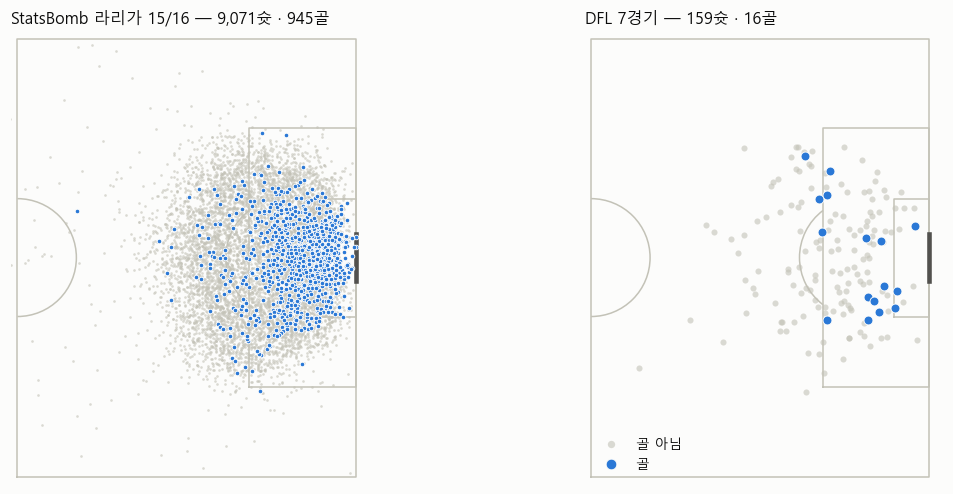

In [5]:
def draw_half(ax, x0=52.5, ylim=(-1, 69)):
    """정규 좌표(105 x 68 m, 공격 골대는 x=105)의 공격 진영."""
    kw = dict(color=BASE, lw=1, zorder=0)
    ax.plot([x0, 105, 105, x0, x0], [0, 0, 68, 68, 0], **kw)
    ax.plot([88.5, 105, 105, 88.5, 88.5], [13.84, 13.84, 54.16, 54.16, 13.84], **kw)   # 페널티 박스
    ax.plot([99.5, 105, 105, 99.5, 99.5], [24.84, 24.84, 43.16, 43.16, 24.84], **kw)   # 골 에어리어
    ax.add_patch(Arc((94, 34), 18.3, 18.3, theta1=127, theta2=233, **kw))
    if x0 <= 52.5:
        ax.add_patch(Arc((52.5, 34), 18.3, 18.3, theta1=-90, theta2=90, **kw))
    ax.plot([105, 105], [34 - G.POST, 34 + G.POST], color=INK2, lw=3, zorder=1)       # 골문
    ax.set_xlim(x0 - 1, 107); ax.set_ylim(*ylim); ax.set_aspect("equal"); ax.axis("off")


def dfl_canon(s):
    """DFL 이벤트 한 행 -> 정규 좌표의 슈터 위치, 미러링 여부 (build_dataset.build_dfl과 같은 규칙)."""
    xt, yt = s["ev.X-PositionFromTracking"], s["ev.Y-PositionFromTracking"]
    flip = abs(xt - 105) > abs(xt)
    return G.from_dfl_tracking([xt - 52.5, yt - 34.0], flip)[0], flip


dxy = shots.set_index("ev.EventId").loc[dfl.shot_id].apply(lambda s: dfl_canon(s)[0], axis=1)
dfl["sx"], dfl["sy"] = [p[0] for p in dxy], [p[1] for p in dxy]
sb["sx"], sb["sy"] = sb.x_raw * G.SB_SX, sb.y_raw * G.SB_SY

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, d, name, s0, s1 in [(axes[0], sb, "StatsBomb 라리가 15/16", 3, 9), (axes[1], dfl, "DFL 7경기", 16, 34)]:
    draw_half(ax)
    miss, goal = d[d.goal == 0], d[d.goal == 1]
    ax.scatter(miss.sx, miss.sy, s=s0, color=BASE, alpha=0.6, lw=0, label="골 아님")
    ax.scatter(goal.sx, goal.sy, s=s1, color=BLUE, edgecolors=SURF, linewidths=0.6, label="골")
    ax.set_title(f"{name} — {len(d):,}슛 · {len(goal):,}골", loc="left", fontsize=10.5)
axes[1].legend(loc="lower left", fontsize=9, markerscale=1.2)
plt.tight_layout(); plt.show()

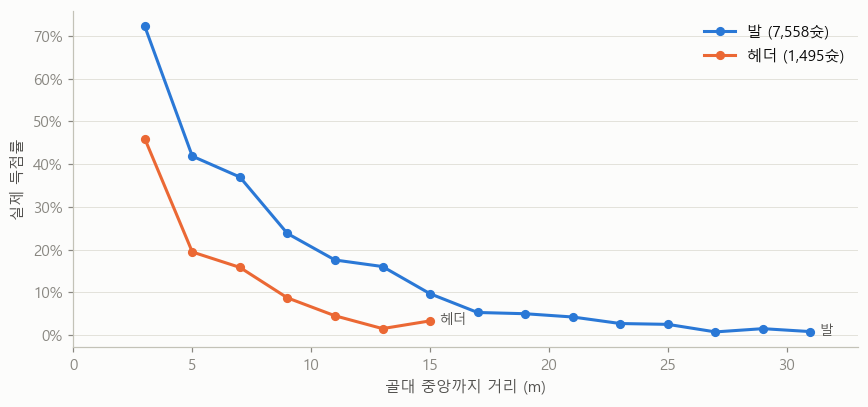

In [6]:
# 거리별 실제 득점률 — 헤더는 같은 거리에서도 훨씬 낮다 (점: 표본 30슛 이상 구간만)
bins = np.arange(0, 34, 2)
fig, ax = plt.subplots(figsize=(8, 3.8))
for name, m, c in [("발", sb.body_part.str.contains("Foot"), BLUE), ("헤더", sb.body_part == "Head", ORANGE)]:
    t = sb[m].groupby(pd.cut(sb[m].dist, bins), observed=True).goal.agg(["mean", "size"])
    t = t[t["size"] >= 30]
    xs = [iv.mid for iv in t.index]
    ax.plot(xs, t["mean"], "-o", color=c, lw=2, ms=5, label=f"{name} ({m.sum():,}슛)")
    ax.annotate(name, (xs[-1], t["mean"].iloc[-1]), xytext=(6, 0), textcoords="offset points",
                color=INK2, va="center", fontsize=9)
ax.set(xlabel="골대 중앙까지 거리 (m)", ylabel="실제 득점률", xlim=(0, 33))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend(loc="upper right"); ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

## 2. 슛 한 개 들여다보기

회색 삼각형은 슈터에서 양 골포스트까지의 **슛 콘**이다. 프리즈프레임 피처가 여기서 계산된다.
- `open_frac`: 슈터에서 골문으로 쏜 광선 중 아무에게도 막히지 않은 비율
- `n_def_cone`: 콘 안에 있는 필드 수비수 수

StatsBomb은 **방송 화면에 보인 선수만** 기록하고, DFL 트래킹은 22명 전원이 찍힌다.

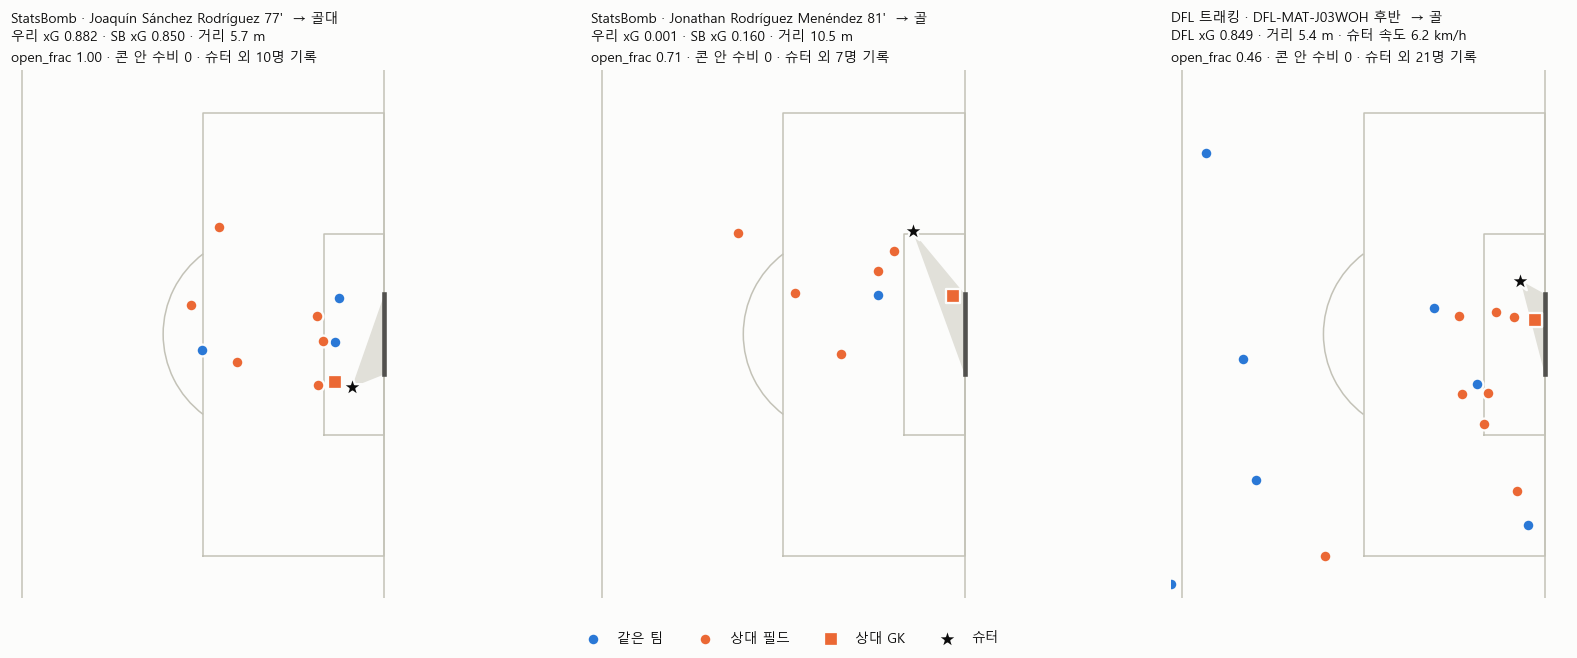

In [7]:
_sb_ev = {}
def sb_event(mid, shot_id):
    if mid not in _sb_ev:
        with gzip.open(os.path.join(SB_DIR, f"events_{mid}.json.gz"), "rb") as fh:
            _sb_ev[mid] = {e["id"]: e for e in json.loads(fh.read().decode())}
    return _sb_ev[mid][shot_id]

FF_PATH = os.path.join(OUT, "freeze_frames.parquet")    # DFL 원본을 파싱해야 생긴다 (저장소에는 없음)
ffr = pd.read_parquet(FF_PATH) if os.path.exists(FF_PATH) else None
players = pd.read_csv(os.path.join(OUT, "players.csv"))
GKS = set(players.loc[players.PlayingPosition == "TW", "PersonId"])
RESULT = {"Goal": "골", "Off T": "빗나감", "Wayward": "크게 빗나감", "Saved": "선방", "Blocked": "블록",
          "Post": "골대", "Saved Off Target": "선방", "Saved to Post": "선방 후 골대",
          "SuccessfulShot": "골", "ShotWide": "빗나감", "SavedShot": "선방", "BlockedShot": "블록",
          "ShotWoodWork": "골대", "OtherShot": "기타"}


def draw_frame(ax, sx, sy, opp, opp_gk, mate, title):
    # 슈터와 골문 주변만 확대 (범위 밖 선수는 잘린다)
    draw_half(ax, x0=min(72, sx - 8), ylim=(min(10, sy - 8), max(58, sy + 8)))
    ax.add_patch(Polygon([[sx, sy], [105, 34 + G.POST], [105, 34 - G.POST]],
                         facecolor=GRID, edgecolor="none", zorder=0))
    ring = dict(edgecolors=SURF, linewidths=1.5, zorder=3)
    ax.scatter(mate[:, 0], mate[:, 1], s=60, color=BLUE, label="같은 팀", **ring)
    ax.scatter(opp[~opp_gk, 0], opp[~opp_gk, 1], s=60, color=ORANGE, label="상대 필드", **ring)
    ax.scatter(opp[opp_gk, 0], opp[opp_gk, 1], s=90, marker="s", color=ORANGE, label="상대 GK", **ring)
    ax.scatter([sx], [sy], s=200, marker="*", color=INK, label="슈터", **ring)
    ax.set_title(title, loc="left", fontsize=9, linespacing=1.5)


def show_sb(shot_id, ax):
    r = sb.loc[sb.shot_id == shot_id].iloc[0]
    e = sb_event(r.match_id, shot_id)
    ff = e["shot"].get("freeze_frame") or []
    opp = [p for p in ff if not p["teammate"]]
    pts = lambda ps: G.from_statsbomb([p["location"] for p in ps])
    gk = np.array([p.get("position", {}).get("name") == "Goalkeeper" for p in opp], dtype=bool)
    out = e["shot"]["outcome"]["name"]
    draw_frame(ax, r.sx, r.sy, pts(opp), gk, pts([p for p in ff if p["teammate"]]),
               f"StatsBomb · {e['player']['name']} {r.minute}'  → {RESULT.get(out, out)}\n"
               f"우리 xG {r.xg_ours:.3f} · SB xG {r.ref_xg:.3f} · 거리 {r.dist:.1f} m\n"
               f"open_frac {r.open_frac:.2f} · 콘 안 수비 {int(r.n_def_cone)} · 슈터 외 {int(r.n_visible)}명 기록")


def show_dfl(event_id, ax):
    s = shots.loc[shots["ev.EventId"] == event_id].iloc[0]
    r = dfl.loc[dfl.shot_id == event_id].iloc[0]
    (sx, sy), flip = dfl_canon(s)
    fr = ffr[(ffr.MatchId == s["ev.MatchId"]) & (ffr.N == int(s["ev.CalculatedFrame"]))]
    P = fr[~fr.TeamId.isin(["BALL", "referee"])]
    xy = G.from_dfl_tracking(np.c_[P.X, P.Y], flip)
    me = (P.PersonId == s["Player"]).values
    opp, mate = (P.TeamId != s["Team"]).values & ~me, (P.TeamId == s["Team"]).values & ~me
    half = {"firstHalf": "전반", "secondHalf": "후반"}.get(fr.GameSection.iloc[0], "")
    draw_frame(ax, sx, sy, xy[opp], P.PersonId.isin(GKS).values[opp], xy[mate],
               f"DFL 트래킹 · {s['ev.MatchId']} {half}  → {RESULT.get(s['outcome'], s['outcome'])}\n"
               f"DFL xG {r.ref_xg:.3f} · 거리 {r.dist:.1f} m · 슈터 속도 {r.shooter_speed:.1f} km/h\n"
               f"open_frac {r.open_frac:.2f} · 콘 안 수비 {int(r.n_def_cone)} · 슈터 외 {len(P) - 1}명 기록")


big_miss = sb[sb.goal == 0].nlargest(1, "xg_ours").shot_id.iloc[0]   # 모델이 가장 확신했는데 안 들어간 슛
wonder = sb[sb.goal == 1].nsmallest(1, "xg_ours").shot_id.iloc[0]    # 모델이 가장 낮게 봤는데 들어간 골
dfl_ex = dfl.nlargest(1, "ref_xg").shot_id.iloc[0]                    # DFL에서 xG가 가장 높은 슛

panels = 3 if ffr is not None else 2
fig, axes = plt.subplots(1, panels, figsize=(5.4 * panels, 6))
show_sb(big_miss, axes[0]); show_sb(wonder, axes[1])
if ffr is not None:
    show_dfl(dfl_ex, axes[2])
else:
    print("DFL 트래킹 장면은 건너뜀: out/freeze_frames.parquet이 없다 (Dfl/에 원본을 넣고 run_all.py를 돌리면 생김)")
h, l = axes[-1].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=4, fontsize=9)
plt.tight_layout(rect=(0, 0.06, 1, 1)); plt.show()

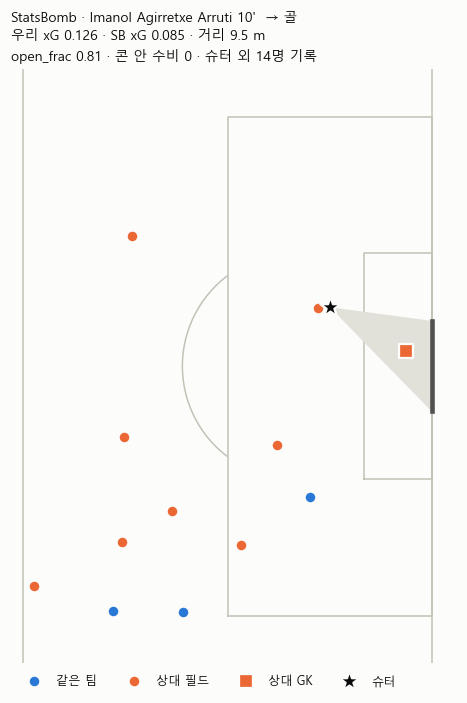

In [8]:
# 직접 골라보기 — 조건을 바꿔 가며 반복 실행 (random_state=None이라 매번 다른 슛)
pick = sb[(sb.body_part == "Head") & (sb.goal == 1)].sample(1).shot_id.iloc[0]
fig, ax = plt.subplots(figsize=(6, 6.5)); show_sb(pick, ax)
ax.legend(loc="upper left", bbox_to_anchor=(0, 0), ncol=4, fontsize=8); plt.tight_layout(); plt.show()

## 3. 성능

비페널티 슛을 **경기 단위 · 시간순**으로 나눴다.

| 구간 | 경기 | 용도 |
|---|---|---|
| dev | 시즌 앞 80% (304경기) | 피처·모델 비교. 안에서 경기 단위 GroupKFold(5) |
| test | 시즌 마지막 20% (76경기) | dev 전체로 학습한 모델을 **한 번만** 평가 = 최종 성능 |

- 최종 모델(★)은 dev CV AUC가 가장 높은 것으로 자동 선택된다. test 점수를 보고 고르지 않는다.
- 단계는 누적이다: A 위치+부위 → B 어시스트·포제션 → C 프리즈프레임 → D 분석관 태그. P는 DFL에도 있는 공통 피처만 쓴 버전.
- CI는 경기 단위 부트스트랩 1000회. 기준선은 StatsBomb 자체 xG(훨씬 많은 데이터로 학습됨), 목표 AUC 0.83.

In [9]:
ci = lambda lo, hi: [f"[{a:.3f}, {b:.3f}]" for a, b in zip(lo, hi)]
tbl = pd.DataFrame({
    "선택": np.where(res.selected, "★", ""), "단계": res.variant, "피처 구성": res.label, "모델": res.model,
    "피처 수": res.n_feat, "dev CV AUC": res.auc, "dev 95% CI": ci(res.auc_lo, res.auc_hi),
    "test AUC": res.test_auc, "test 95% CI": ci(res.test_auc_lo, res.test_auc_hi),
    "test SB 대비": res.test_d_vs_sb, "test logloss": res.test_logloss, "test Σ예측/Σ골": res.test_calib,
})
tbl.style.format({"피처 수": "{:.0f}", "dev CV AUC": "{:.4f}", "test AUC": "{:.4f}", "test SB 대비": "{:+.4f}",
                  "test logloss": "{:.4f}", "test Σ예측/Σ골": "{:.3f}"}, na_rep="").hide(axis="index")

선택,단계,피처 구성,모델,피처 수,dev CV AUC,dev 95% CI,test AUC,test 95% CI,test SB 대비,test logloss,test Σ예측/Σ골
,A,위치+부위,LogReg,29,0.8068,"[0.791, 0.823]",0.7876,"[0.752, 0.824]",-0.0438,0.2863,0.969
,A,위치+부위,GBM,29,0.7981,"[0.782, 0.815]",0.7896,"[0.755, 0.823]",-0.0418,0.2847,0.964
,B,+어시스트·포제션,LogReg,58,0.8106,"[0.795, 0.827]",0.8037,"[0.768, 0.839]",-0.0277,0.2789,0.978
,B,+어시스트·포제션,GBM,58,0.8020,"[0.785, 0.820]",0.8133,"[0.780, 0.845]",-0.0181,0.2736,0.956
★,C,+프리즈프레임,LogReg,76,0.8272,"[0.811, 0.844]",0.8125,"[0.779, 0.847]",-0.0189,0.2682,0.982
,C,+프리즈프레임,GBM,76,0.8194,"[0.804, 0.836]",0.8222,"[0.787, 0.857]",-0.0092,0.2625,0.953
,D,+분석관 태그,LogReg,78,0.8271,"[0.811, 0.843]",0.8128,"[0.779, 0.847]",-0.0186,0.2675,0.979
,D,+분석관 태그,GBM,78,0.8212,"[0.805, 0.838]",0.8173,"[0.782, 0.851]",-0.0141,0.2646,0.950
,P,공통 피처,LogReg,21,0.8251,"[0.809, 0.841]",0.8185,"[0.784, 0.851]",-0.0129,0.2664,0.965
,P,공통 피처,GBM,21,0.8176,"[0.802, 0.834]",0.8235,"[0.788, 0.857]",-0.0079,0.2645,0.958


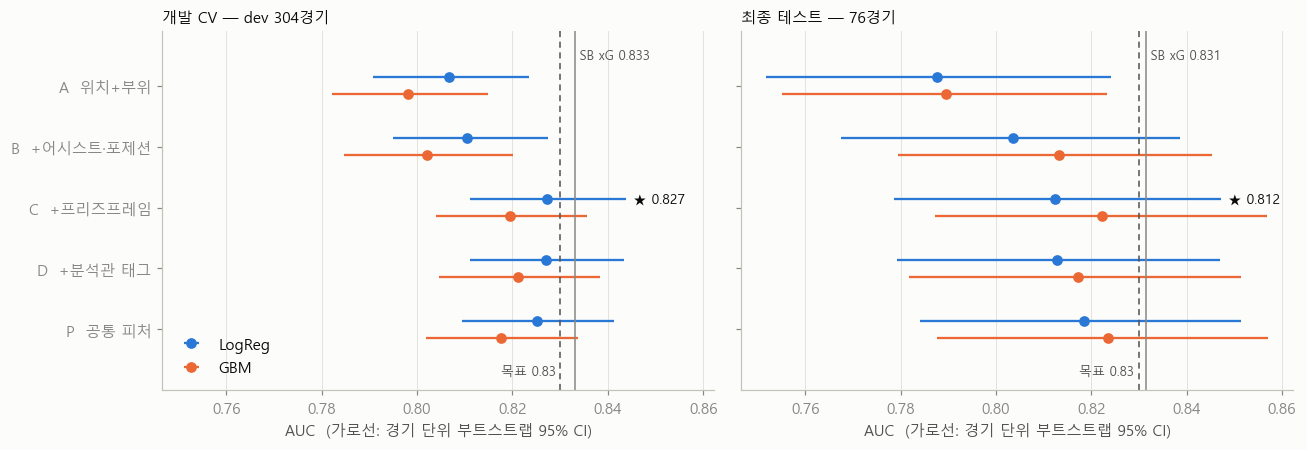

In [10]:
n_dev, n_test = (oof.groupby("split").match_id.nunique()[k] for k in ("dev", "test"))
lr = res[res.model == "LogReg"].reset_index(drop=True)
ypos = np.arange(len(lr))[::-1]
off = {"LogReg": 0.14, "GBM": -0.14}
ref = res[res.variant == "REF"].iloc[0]
sel_y = ypos[lr.index[lr.variant == SEL.variant][0]] + off[SEL.model]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True, sharey=True)
for ax, pre, title in [(axes[0], "", f"개발 CV — dev {n_dev}경기"), (axes[1], "test_", f"최종 테스트 — {n_test}경기")]:
    for m, c in [("LogReg", BLUE), ("GBM", ORANGE)]:
        r = res[res.model == m]
        a, lo, hi = r[pre + "auc"], r[pre + "auc_lo"], r[pre + "auc_hi"]
        ax.errorbar(a, ypos + off[m], xerr=[a - lo, hi - a], fmt="o", color=c, ms=6, lw=1.5, capsize=0, label=m)
    ax.axvline(ref[pre + "auc"], color=MUTED, lw=1)
    ax.text(ref[pre + "auc"], ypos[0] + 0.45, f" SB xG {ref[pre + 'auc']:.3f}", color=INK2, fontsize=8.5)
    ax.axvline(0.83, color=INK2, lw=1, ls=(0, (4, 3)))
    ax.text(0.83, -0.75, "목표 0.83 ", color=INK2, fontsize=8.5, ha="right")
    ax.annotate(f"★ {SEL[pre + 'auc']:.3f}", (SEL[pre + "auc_hi"], sel_y), xytext=(5, 0),
                textcoords="offset points", va="center", fontsize=9, color=INK)
    ax.set_title(title, loc="left", fontsize=10); ax.grid(axis="y", visible=False)
    ax.set_xlabel("AUC  (가로선: 경기 단위 부트스트랩 95% CI)")
axes[0].set_yticks(ypos, lr.variant + "  " + lr.label); axes[0].set_ylim(-1, ypos[0] + 0.9)
axes[0].legend(loc="lower left")
plt.tight_layout(); plt.show()

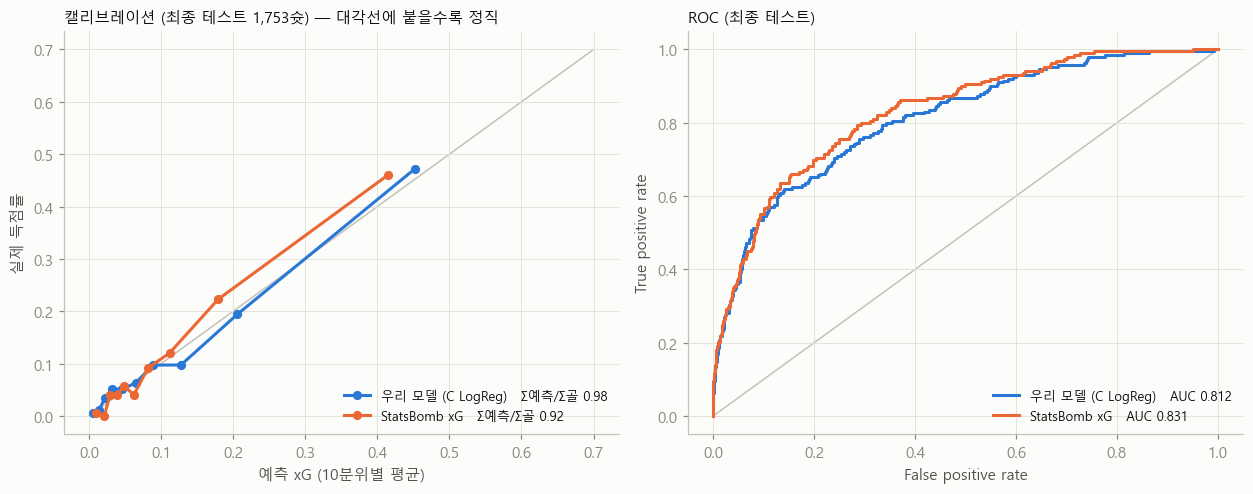

In [11]:
# 최종 테스트 구간만
te = (sb.split == "test").values
yt = y[te]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.6))
for name, p, c in [(f"우리 모델 ({SEL.variant} {SEL.model})", sb.xg_ours.values[te], BLUE),
                   ("StatsBomb xG", sb.ref_xg.values[te], ORANGE)]:
    q = pd.qcut(p, 10, labels=False, duplicates="drop")
    cal = pd.DataFrame({"p": p, "y": yt}).groupby(q).mean()
    a1.plot(cal.p, cal.y, "-o", color=c, lw=2, ms=5, label=f"{name}   Σ예측/Σ골 {p.sum() / yt.sum():.2f}")
    fpr, tpr, _ = roc_curve(yt, p)
    a2.plot(fpr, tpr, color=c, lw=2, label=f"{name}   AUC {roc_auc_score(yt, p):.3f}")
a1.plot([0, 0.7], [0, 0.7], color=BASE, lw=1, zorder=0)
a1.set(xlabel="예측 xG (10분위별 평균)", ylabel="실제 득점률",
       title=f"캘리브레이션 (최종 테스트 {te.sum():,}슛) — 대각선에 붙을수록 정직")
a2.plot([0, 1], [0, 1], color=BASE, lw=1, zorder=0)
a2.set(xlabel="False positive rate", ylabel="True positive rate", title="ROC (최종 테스트)")
for a in (a1, a2):
    a.legend(loc="lower right", fontsize=8.5); a.title.set(fontsize=10, ha="left", x=0)
plt.tight_layout(); plt.show()

In [12]:
# 어디서 SB xG에 밀리나 — 차이가 음수면 우리가 낮다 (빨강), 양수면 우리가 높다 (파랑)
# 표본을 늘리려고 전체 슛 사용: dev는 CV 예측, test는 최종 모델 예측 (둘 다 그 경기를 안 본 모델)
groups = {
    "부위": np.where(sb.body_part == "Head", "헤더", "발·기타"),
    "위치": np.where(sb.inside_box == 1, "박스 안", "박스 밖"),
    "상황": sb.shot_type.map({"Open Play": "오픈플레이", "Free Kick": "직접 프리킥"}).fillna("기타").values,
    "1:1 태그": np.where(sb.one_on_one == 1, "1:1", "그 외"),
    "플레이 패턴": sb.play_pattern.values,
}
rows = []
for k, v in groups.items():
    for val in pd.unique(v):
        m = v == val
        if m.sum() < 60 or y[m].sum() < 5:
            continue
        a_us, a_sb = roc_auc_score(y[m], sb.xg_ours.values[m]), roc_auc_score(y[m], sb.ref_xg.values[m])
        rows.append({"구분": k, "값": val, "슛": m.sum(), "골": y[m].sum(), "AUC 우리": a_us, "AUC SB": a_sb,
                     "차이": a_us - a_sb, "Σ예측/Σ골": sb.xg_ours.values[m].sum() / y[m].sum()})
(pd.DataFrame(rows).style.format({"AUC 우리": "{:.3f}", "AUC SB": "{:.3f}", "차이": "{:+.3f}", "Σ예측/Σ골": "{:.2f}"})
   .background_gradient(subset=["차이"], cmap="RdBu", vmin=-0.05, vmax=0.05).hide(axis="index"))

구분,값,슛,골,AUC 우리,AUC SB,차이,Σ예측/Σ골
부위,발·기타,7576,775,0.835,0.844,-0.010,1.00
부위,헤더,1495,170,0.765,0.767,-0.001,0.99
위치,박스 안,5758,847,0.796,0.808,-0.012,1.00
위치,박스 밖,3313,98,0.734,0.743,-0.010,1.01
상황,오픈플레이,8661,916,0.828,0.838,-0.010,1.00
상황,직접 프리킥,409,29,0.662,0.702,-0.040,1.03
1:1 태그,그 외,8539,809,0.822,0.829,-0.007,1.00
1:1 태그,1:1,532,136,0.732,0.764,-0.032,0.99
플레이 패턴,Regular Play,3062,339,0.833,0.844,-0.011,1.03
플레이 패턴,From Corner,1527,136,0.789,0.801,-0.012,0.98


## 4. 피처 하나만으로 골을 얼마나 가르나

피처 하나를 그대로 점수로 쓸 때의 AUC다. 0.5면 정보가 없고, 방향은 화살표로 표시했다 (↑ 클수록 골, ↓ 작을수록 골).
모델 계수가 아니라 데이터 자체의 신호라서 피처끼리 상관이 있어도 해석이 흔들리지 않는다.

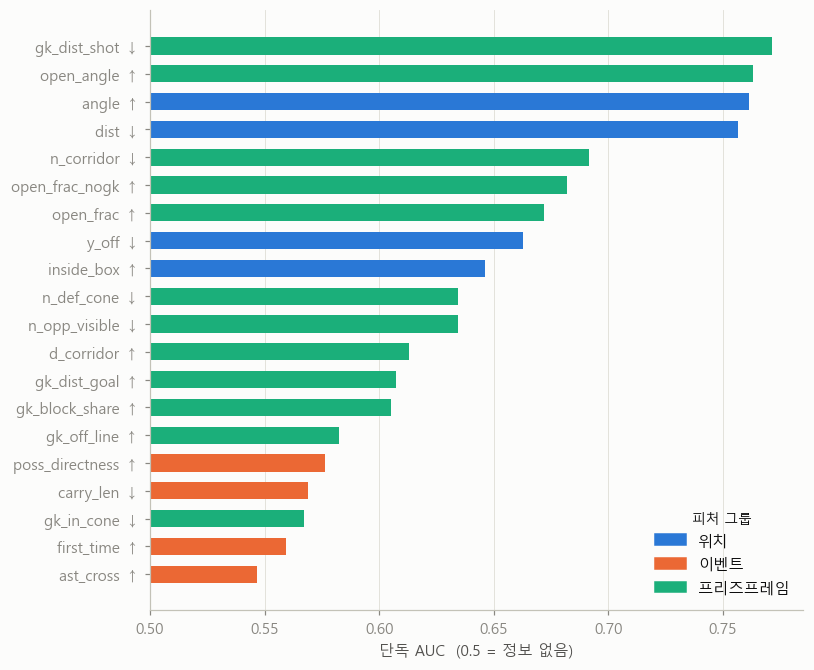

,피처,그룹,단독 AUC,방향
0,gk_dist_shot,프리즈프레임,0.771,↓
1,open_angle,프리즈프레임,0.763,↑
2,angle,위치,0.761,↑
3,dist,위치,0.756,↓
4,n_corridor,프리즈프레임,0.691,↓
5,open_frac_nogk,프리즈프레임,0.682,↑
6,open_frac,프리즈프레임,0.672,↑
7,y_off,위치,0.663,↓
8,inside_box,위치,0.646,↑
9,n_def_cone,프리즈프레임,0.635,↓


In [13]:
group_of = {**{c: "위치" for c in BASE_NUM}, **{c: "이벤트" for c in EVT_NUM}, **{c: "프리즈프레임" for c in FF_NUM}}
gcol = {"위치": BLUE, "이벤트": ORANGE, "프리즈프레임": AQUA}
rows = []
for c, grp in group_of.items():
    x = sb[c].astype(float)
    a = roc_auc_score(y, x.fillna(x.median()))
    rows.append({"피처": c, "그룹": grp, "단독 AUC": max(a, 1 - a), "방향": "↑" if a >= 0.5 else "↓"})
fa = pd.DataFrame(rows).sort_values("단독 AUC", ascending=False).reset_index(drop=True)

from matplotlib.patches import Patch
top = fa.head(20)[::-1]
fig, ax = plt.subplots(figsize=(7.5, 6.2))
ax.barh(top.피처 + " " + top.방향, top["단독 AUC"] - 0.5, left=0.5, height=0.62,
        color=[gcol[g] for g in top.그룹])
ax.set_xlim(0.5, None); ax.set_xlabel("단독 AUC  (0.5 = 정보 없음)")
ax.grid(axis="y", visible=False)
ax.legend(handles=[Patch(color=c, label=g) for g, c in gcol.items()], loc="lower right",
          title="피처 그룹", title_fontsize=9)
plt.tight_layout(); plt.show()
fa.round(3)

## 5. DFL: StatsBomb 사전학습(v2) vs DFL 단독

**v2** (`src/train_v2.py`): SB로 학습한 공통 피처 모델(P)은 고정하고, 그 위에 조정값 몇 개만 DFL로 학습한다.

```
xG_DFL = σ( z_SB + a + b·(z_SB − z̄) + γ·트래킹 )
```

- **M0**: SB 모델 그대로 — DFL을 한 번도 안 봤으므로 이것 자체가 외부 테스트
- **M1**: + 리그 보정 (a: 전체 득점 수준, b: 확신 정도)
- **M2**: + 리그 보정 + 트래킹 (γ: 슈터 속도, 가까운 수비 3명의 접근거리)

**DFL 단독** (`src/train_dfl.py`): StatsBomb 없이 DFL로만 학습한 비교 기준 (LogReg, 규제 강도는 v2와 같게 사전 고정).
- **DFL0**: 거리·각도만
- **DFL1**: M0와 같은 공통 피처 21개 → M0와 비교하면 'StatsBomb으로 학습한 효과'
- **DFL2**: M2와 같은 입력 (공통 피처 + 트래킹 2개)

평가는 둘 다 같다: 한 경기씩 빼고 나머지 6경기로 학습/조정 → 빠진 경기 예측, 7번 반복.

DFL 비페널티 골은 16개뿐이라 CI가 매우 넓다. 모델 간 차이는 **방향 확인용**으로만 읽는다.

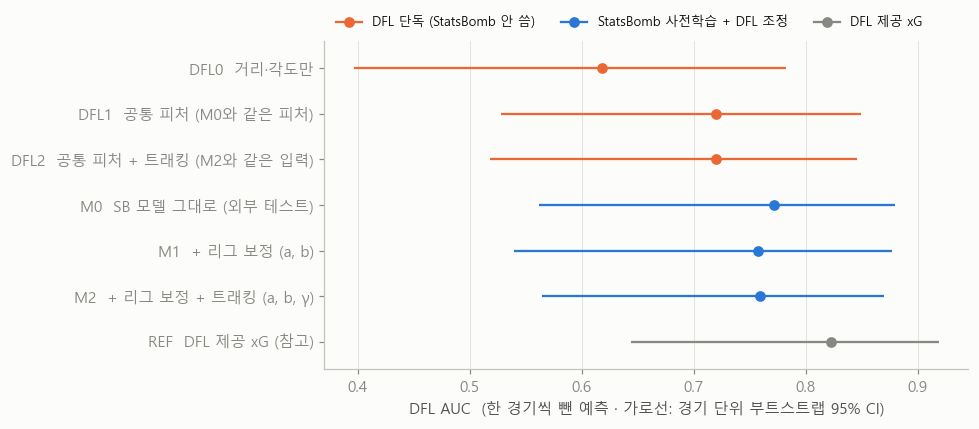

모델,설명,AUC,95% CI,logloss,예측 골,실제 골
DFL0,거리·각도만,0.618000,"[0.40, 0.78]",0.320400,16.400000,16
DFL1,공통 피처 (M0와 같은 피처),0.720000,"[0.53, 0.85]",0.293900,16.200000,16
DFL2,공통 피처 + 트래킹 (M2와 같은 입력),0.720000,"[0.52, 0.85]",0.291400,16.300000,16
M0,SB 모델 그대로 (외부 테스트),0.771000,"[0.56, 0.88]",0.291400,11.700000,16
M1,"+ 리그 보정 (a, b)",0.758000,"[0.54, 0.88]",0.299400,13.600000,16
M2,"+ 리그 보정 + 트래킹 (a, b, γ)",0.760000,"[0.56, 0.87]",0.290600,14.000000,16
REF,DFL 제공 xG (참고),0.823000,"[0.64, 0.92]",0.250400,14.600000,16


,param,value,odds배수
0,a,0.188,1.207
1,b,-0.074,0.928
2,γ_shooter_speed,0.334,1.396
3,γ_def_closing,-0.130,0.878


In [14]:
from matplotlib.lines import Line2D
v2 = pd.read_csv(os.path.join(OUT, "v2_results.csv"))
dfo = pd.read_csv(os.path.join(OUT, "dfl_results.csv"))
prm = pd.read_csv(os.path.join(OUT, "v2_params.csv"))
cmp5 = pd.concat([dfo[dfo.model != "REF"], v2], ignore_index=True)     # DFL0~2, M0~2, REF
col5 = lambda m: ORANGE if m.startswith("DFL") else (MUTED if m == "REF" else BLUE)

fig, ax = plt.subplots(figsize=(9, 4))
yp = np.arange(len(cmp5))[::-1]
for yy, (_, r) in zip(yp, cmp5.iterrows()):
    ax.errorbar(r.auc, yy, xerr=[[r.auc - r.auc_lo], [r.auc_hi - r.auc]], fmt="o", ms=6, lw=1.5, capsize=0,
                color=col5(r.model))
ax.set_yticks(yp, cmp5.model + "  " + cmp5.desc); ax.set_ylim(-0.6, len(cmp5) - 0.4)
ax.set_xlabel("DFL AUC  (한 경기씩 뺀 예측 · 가로선: 경기 단위 부트스트랩 95% CI)")
ax.grid(axis="y", visible=False)
ax.legend(handles=[Line2D([], [], color=c, marker="o", label=l) for c, l in
                   [(ORANGE, "DFL 단독 (StatsBomb 안 씀)"), (BLUE, "StatsBomb 사전학습 + DFL 조정"), (MUTED, "DFL 제공 xG")]],
          loc="lower left", bbox_to_anchor=(0, 1.0), ncol=3, fontsize=8.5)
plt.tight_layout(); plt.show()

display(pd.DataFrame({
    "모델": cmp5.model, "설명": cmp5.desc, "AUC": cmp5.auc.round(3),
    "95% CI": [f"[{a:.2f}, {b:.2f}]" for a, b in zip(cmp5.auc_lo, cmp5.auc_hi)],
    "logloss": cmp5.logloss.round(4), "예측 골": cmp5.pred_goals.round(1), "실제 골": int(dfl.goal.sum()),
}).style.hide(axis="index"))
prm.assign(odds배수=np.exp(prm.value)).round(3)     # v2: 7경기 전체로 학습한 조정값 (0이면 SB 모델 그대로)

## 다시 돌리기

0번 셀이 전체를 다시 계산한다. 코드 일부만 고쳤다면 터미널(프로젝트 루트)에서 해당 단계부터 돌리고, 0번 셀의 `RUN_PIPELINE`을 `False`로 바꿔 나머지를 실행해도 된다.

```
python run_all.py                  # 전체 — DFL 트래킹 파싱 포함, 약 4~5분
python run_all.py --from dataset   # 피처(geometry.py, build_dataset.py) 수정 후
python run_all.py --from train     # 모델(train_v1.py) 수정 후 — v1 학습 + v2 파인튜닝
python run_all.py --only finetune  # 파인튜닝(train_v2.py)만 수정 후, 몇 초
python run_all.py --only dfl_only  # DFL 단독 모델(train_dfl.py)만 수정 후, 몇 초
python run_all.py --list           # 단계 목록
```